In [4]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import xgboost as xgb
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score



In [5]:
train_df=pd.read_csv('train_fraud_detection.csv')
test_df=pd.read_csv('test_fraud_detection.csv')
train_df.head()

,city_pop,amount,time_diff,tx_count_24h,location_change,device_change,distance_km,hour,day_of_week,is_weekend,anomaly_score,is_fraud
0,-0.242085,-0.233664,-0.092623,0.362564,0,0,0.504115,16,1,0,0.164830,0
1,-0.290199,-0.204049,-0.544786,-0.286348,0,0,-0.544436,20,6,1,0.153877,0
2,-0.287049,-0.112376,0.089825,0.362564,0,0,-0.012140,8,1,0,0.164189,0
3,-0.290597,-0.380479,-0.573410,-0.286348,0,0,1.104335,19,6,1,0.152886,0
4,-0.289466,0.024756,-0.299769,-1.259717,0,0,-1.066904,17,0,0,0.129291,0


In [6]:
is_fraud_counts = train_df['is_fraud'].value_counts()
print(is_fraud_counts)

is_fraud
0    1031335
1       6005
Name: count, dtype: int64


In [7]:
X_train=train_df.drop('is_fraud', axis=1)
y_train=train_df['is_fraud']    
X_test=test_df.drop('is_fraud', axis=1)
y_test=test_df['is_fraud']

In [8]:
model=xgb.XGBClassifier( random_state=42,learning_rate=0.1, n_estimators=100, max_depth=5, subsample=0.8, colsample_bytree=0.8,scale_pos_weight = (len(y_train[y_train==0]) / len(y_train[y_train==1])))
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [9]:
y_train_pred=model.predict(X_train)
y_test_pred=model.predict(X_test)


In [10]:
print("Training Classification Report:")
print(classification_report(y_train, y_train_pred))
print("Training Confusion Matrix:")
print(confusion_matrix(y_train, y_train_pred))
print("Training Accuracy:", accuracy_score(y_train, y_train_pred))


Training Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98   1031335
           1       0.11      0.96      0.19      6005

    accuracy                           0.95   1037340
   macro avg       0.55      0.96      0.58   1037340
weighted avg       0.99      0.95      0.97   1037340

Training Confusion Matrix:
[[982983  48352]
 [   231   5774]]
Training Accuracy: 0.9531657894229472


In [11]:
print('Testing Classification Report:')
print(classification_report(y_test, y_test_pred))
print('Testing Confusion Matrix:')
print(confusion_matrix(y_test, y_test_pred))
print('Testing Accuracy:', accuracy_score(y_test, y_test_pred))


Testing Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.95      0.98    257834
           1       0.11      0.95      0.19      1501

    accuracy                           0.95    259335
   macro avg       0.55      0.95      0.58    259335
weighted avg       0.99      0.95      0.97    259335

Testing Confusion Matrix:
[[245761  12073]
 [    76   1425]]
Testing Accuracy: 0.9531532573698113


In [12]:

y_proba = model.predict_proba(X_test)[:,1]

threshold = 0.80
y_pred_custom = (y_proba > threshold).astype(int)
print('Custom Threshold Classification Report:')
print(classification_report(y_test, y_pred_custom))
print('Custom Threshold Confusion Matrix:')
print(confusion_matrix(y_test, y_pred_custom))

Custom Threshold Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.98      0.99    257834
           1       0.22      0.88      0.35      1501

    accuracy                           0.98    259335
   macro avg       0.61      0.93      0.67    259335
weighted avg       0.99      0.98      0.99    259335

Custom Threshold Confusion Matrix:
[[253226   4608]
 [   183   1318]]


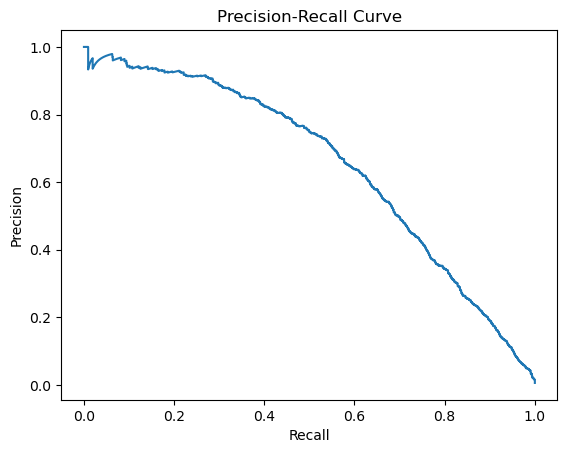

In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [14]:
%pip install joblib xgboost

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import joblib

try:
	joblib.dump(model, "xgb_model.joblib")
	print("Saved model to xgb_model.joblib")
except NameError:
	raise NameError("Model 'model' is not defined. Run the training cell (CELL INDEX: 4) before saving.")

Saved model to xgb_model.joblib
